In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../utaut2_dataset/new_result.xlsx')

In [2]:
act_col = 'Do you currently follow any regular physical activity or wellness practice?'

act_counts = df[act_col].value_counts()
print("Текущая физическая активность (вся выборка, N = 186):")
for val, cnt in act_counts.items():
    print(f"  {val}: {cnt} ({cnt/len(df)*100:.1f}%)")

cols = df.columns.tolist()
scale_cols = cols[13:37]
has_scale = df[scale_cols].notna().all(axis=1)

print(f"\nЗаполнили шкальный блок UTAUT2: {has_scale.sum()}")
print(f"Не заполнили (ветвление анкеты): {(~has_scale).sum()}")

no_scale = df[~has_scale]
print(f"\nВсе {len(no_scale)} респондентов без шкалы ответили на вопрос об активности:")
print(f"  «{no_scale[act_col].unique()[0]}»")
print("Анкета перенаправила их в конец, минуя блок UTAUT2.")

Текущая физическая активность (вся выборка, N = 186):
  Yes, regularly (3 or more times per week): 66 (35.5%)
  Yes, but irregularly (less than 3 times per week): 56 (30.1%)
  No, but I plan to start: 42 (22.6%)
  No, and I have no plans to: 22 (11.8%)

Заполнили шкальный блок UTAUT2: 164
Не заполнили (ветвление анкеты): 22

Все 22 респондентов без шкалы ответили на вопрос об активности:
  «No, and I have no plans to»
Анкета перенаправила их в конец, минуя блок UTAUT2.


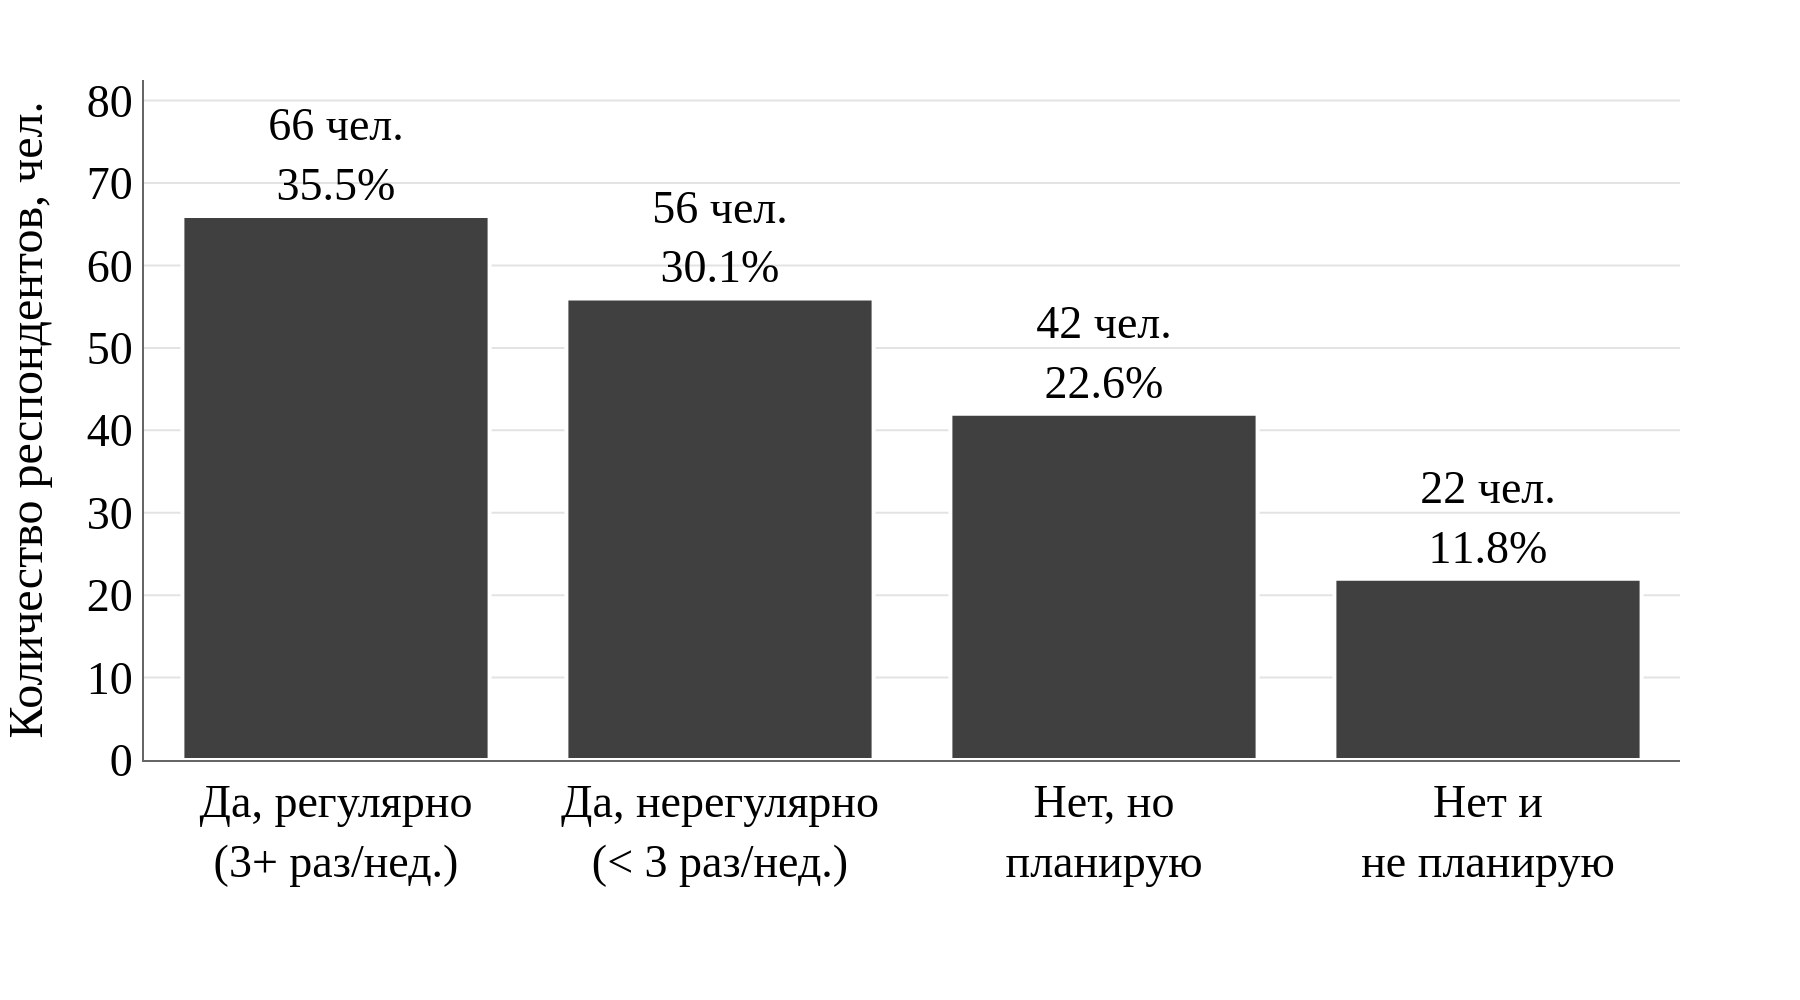

In [3]:
act_ru = {
    'Yes, regularly (3 or more times per week)': 'Да, регулярно<br>(3+ раз/нед.)',
    'Yes, but irregularly (less than 3 times per week)': 'Да, нерегулярно<br>(< 3 раз/нед.)',
    'No, but I plan to start': 'Нет, но<br>планирую',
    'No, and I have no plans to': 'Нет и<br>не планирую'
}
act_order = list(act_ru.keys())
act_counts = df[act_col].value_counts().reindex(act_order)
act_pct = (act_counts / act_counts.sum() * 100).round(1)

fig = go.Figure(data=[go.Bar(
    x=[act_ru[x] for x in act_counts.index], y=act_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(act_counts.values, act_pct.values)],
    textposition='outside', textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])
fig.update_layout(showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(title='', showgrid=False, tickfont=dict(size=23),
        linecolor=AXIS_COLOR, linewidth=1, tickangle=0),
    yaxis=dict(title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23), showgrid=True, gridcolor=GRID_COLOR,
        zeroline=False, linecolor=AXIS_COLOR, linewidth=1, range=[0, act_counts.max()*1.25]),
    margin=dict(l=60, r=60, t=40, b=120), width=900)
fig.show()

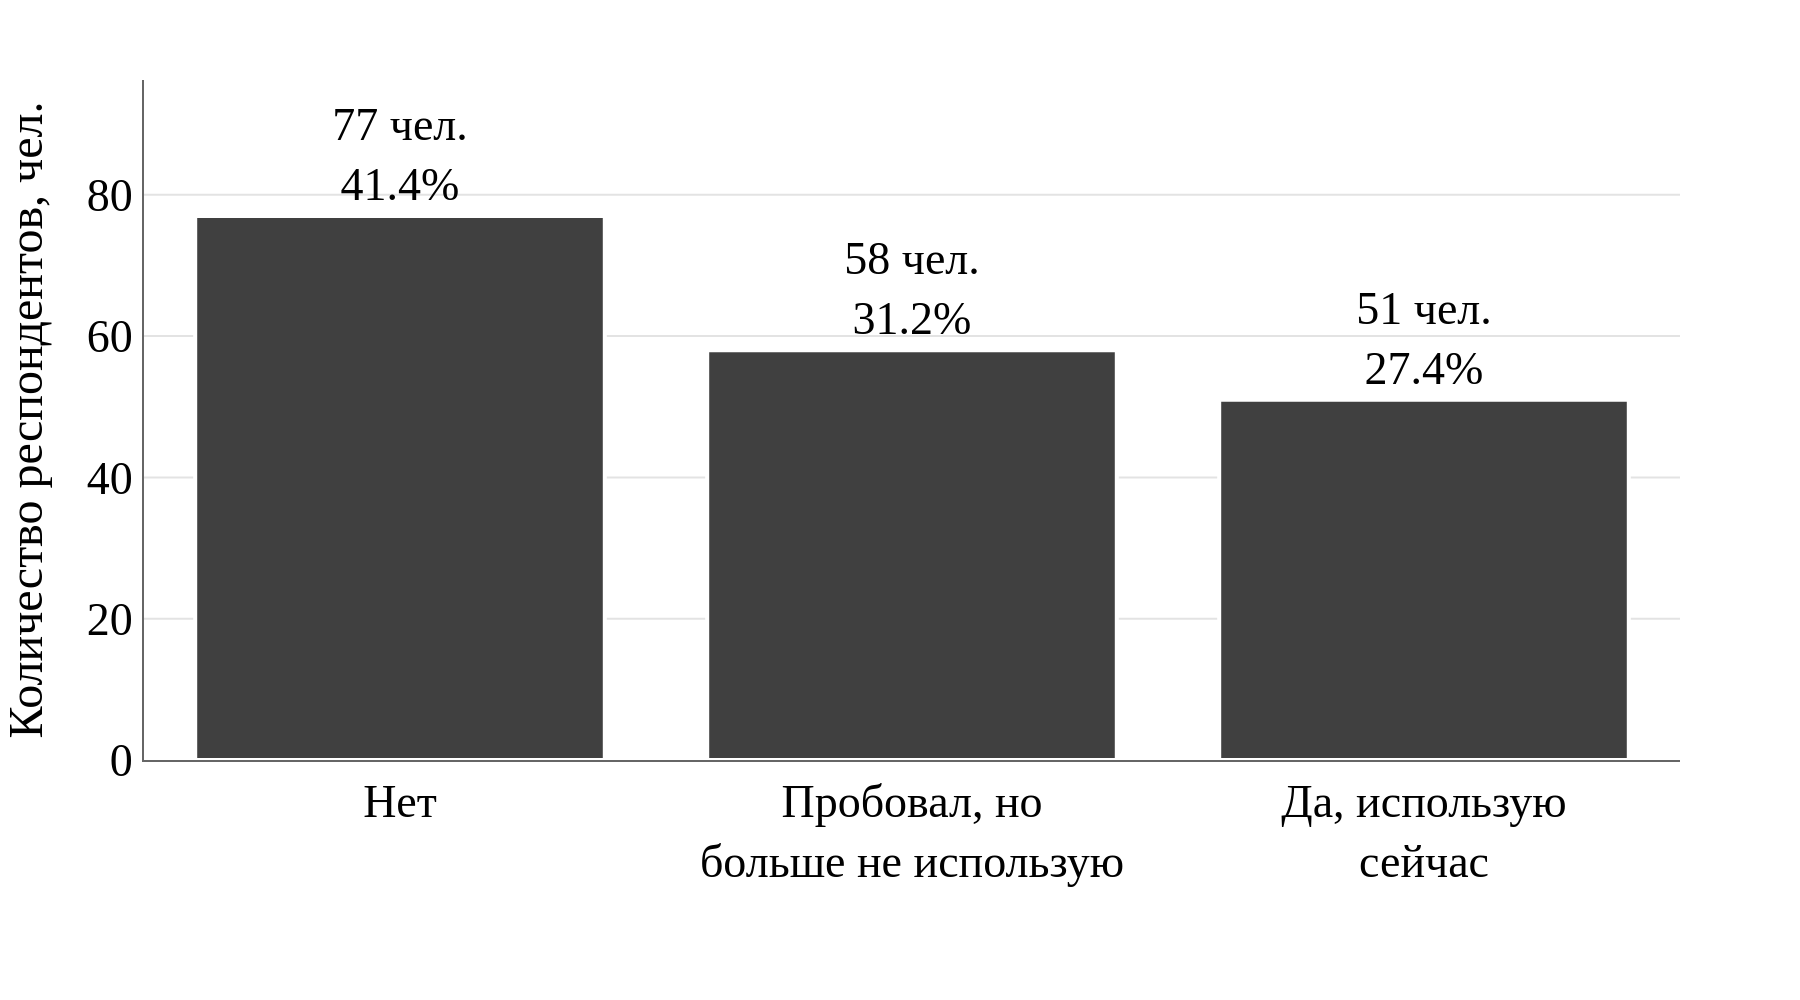

In [4]:
exp_col = 'Have you ever used online fitness or wellness services?'
exp_counts = df[exp_col].value_counts()
exp_pct = (exp_counts / exp_counts.sum() * 100).round(1)
exp_ru = {'No': 'Нет', 'Yes, tried in the past but no longer use them': 'Пробовал, но<br>больше не использую',
           'Yes, currently use them': 'Да, использую<br>сейчас'}

fig = go.Figure(data=[go.Bar(
    x=[exp_ru.get(x, x) for x in exp_counts.index], y=exp_counts.values,
    text=[f'{c} чел.<br>{p}%' for c, p in zip(exp_counts.values, exp_pct.values)],
    textposition='outside', textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])
fig.update_layout(showlegend=False, paper_bgcolor='white', plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(title='', showgrid=False, tickfont=dict(size=23),
        linecolor=AXIS_COLOR, linewidth=1, tickangle=0),
    yaxis=dict(title=dict(text='Количество респондентов, чел.', font=dict(size=24)),
        tickfont=dict(size=23), showgrid=True, gridcolor=GRID_COLOR,
        zeroline=False, linecolor=AXIS_COLOR, linewidth=1, range=[0, exp_counts.max()*1.25]),
    margin=dict(l=60, r=60, t=40, b=120), width=900)
fig.show()